In [1]:
# CELL 1: Install Required Packages


!pip install onnx onnxruntime onnxoptimizer -q


In [2]:
# CELL 2: Import Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import os
import numpy as np
import onnx
import onnxruntime as ort
from onnx import helper, checker, shape_inference
import time

print(f"PyTorch version: {torch.__version__}")
print(f"ONNX version: {onnx.__version__}")
print(f"ONNX Runtime version: {ort.__version__}")

PyTorch version: 2.10.0+cpu
ONNX version: 1.21.0
ONNX Runtime version: 1.23.2


In [3]:
# CELL 3: Model Architecture Definition
"""
Define your Model 5 architecture (EfficientNet-B3 + SegFormer)
"""

class EfficientNetEncoder(nn.Module):
    def __init__(self, model_name='efficientnet_b3', pretrained=False):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, features_only=True)
        self.feature_channels = self.backbone.feature_info.channels()
    
    def forward(self, x):
        return self.backbone(x)


class SegFormerDecoder(nn.Module):
    def __init__(self, encoder_channels, num_classes=1, decoder_dim=256):
        super().__init__()
        self.proj = nn.ModuleList()
        for in_ch in encoder_channels:
            self.proj.append(nn.Sequential(
                nn.Conv2d(in_ch, decoder_dim, 1), 
                nn.BatchNorm2d(decoder_dim), 
                nn.ReLU()
            ))
        self.fusion = nn.Sequential(
            nn.Conv2d(decoder_dim * len(encoder_channels), decoder_dim, 1),
            nn.BatchNorm2d(decoder_dim), 
            nn.ReLU(),
            nn.Conv2d(decoder_dim, decoder_dim, 3, padding=1), 
            nn.BatchNorm2d(decoder_dim), 
            nn.ReLU(),
            nn.Conv2d(decoder_dim, num_classes, 1)
        )
    
    def forward(self, features):
        target_size = features[0].shape[2]
        projected = []
        for i, feat in enumerate(features):
            proj = self.proj[i](feat)
            if proj.shape[2] != target_size:
                proj = F.interpolate(proj, size=(target_size, target_size), mode='bilinear')
            projected.append(proj)
        concat = torch.cat(projected, dim=1)
        out = self.fusion(concat)
        return F.interpolate(out, size=(224, 224), mode='bilinear')


class Model5(nn.Module):
    def __init__(self, num_classes=3, num_seg_classes=1):
        super().__init__()
        self.encoder = EfficientNetEncoder('efficientnet_b3')
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), 
            nn.Flatten(),
            nn.Linear(self.encoder.feature_channels[-1], 512), 
            nn.ReLU(), 
            nn.BatchNorm1d(512), 
            nn.Dropout(0.5),
            nn.Linear(512, 256), 
            nn.ReLU(), 
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        self.seg_decoder = SegFormerDecoder(self.encoder.feature_channels, num_seg_classes, 256)
    
    def forward(self, x):
        features = self.encoder(x)
        class_out = self.classifier(features[-1])
        seg_out = self.seg_decoder(features)
        return class_out, seg_out

print("✅ Model architecture defined")

✅ Model architecture defined


In [4]:
# CELL 4: Load Trained Model
"""
Load your trained model weights
"""

device = torch.device('cpu')

# Update this path to your actual model file
MODEL_PATH = "./models/model5_best_acc.pth"

model = Model5()

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'), strict=False)
    model.eval()
    print(f"✅ Model loaded from {MODEL_PATH}")
else:
    print(f"❌ Model not found at {MODEL_PATH}")
    print(f"Current directory: {os.getcwd()}")
    # List available models if any
    if os.path.exists('./models'):
        print("\nAvailable models:")
        for f in os.listdir('./models'):
            if f.endswith('.pth'):
                print(f"  - {f}")
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}")

# Model information
total_params = sum(p.numel() for p in model.parameters())
model_size_mb = total_params * 4 / 1024 / 1024

print(f"\n📊 Model Information:")
print(f"  Architecture: EfficientNet-B3 + SegFormer")
print(f"  Total parameters: {total_params:,}")
print(f"  Model size (FP32): {model_size_mb:.2f} MB")
print(f"  Input: 224x224x3")
print(f"  Outputs: Classification (3 classes) + Segmentation (1 channel)")

✅ Model loaded from ./models/model5_best_acc.pth

📊 Model Information:
  Architecture: EfficientNet-B3 + SegFormer
  Total parameters: 11,516,460
  Model size (FP32): 43.93 MB
  Input: 224x224x3
  Outputs: Classification (3 classes) + Segmentation (1 channel)


In [5]:
# CELL 5: Export to ONNX Format
"""
Export PyTorch model to ONNX format
"""

def export_to_onnx(model, output_path, dynamic_batch=True):
    """Export model to ONNX format"""
    
    model.eval()
    dummy_input = torch.randn(1, 3, 224, 224)
    
    # Configure dynamic axes for variable batch size
    if dynamic_batch:
        dynamic_axes = {
            'input': {0: 'batch_size'},
            'classification_output': {0: 'batch_size'},
            'segmentation_output': {0: 'batch_size'}
        }
    else:
        dynamic_axes = None
    
    # Export to ONNX
    torch.onnx.export(
        model,
        dummy_input,
        output_path,
        export_params=True,
        opset_version=11,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['classification_output', 'segmentation_output'],
        dynamic_axes=dynamic_axes,
        verbose=False
    )
    
    # Verify the model
    onnx_model = onnx.load(output_path)
    onnx.checker.check_model(onnx_model)
    
    # Get file size
    size_mb = os.path.getsize(output_path) / 1024 / 1024
    
    print(f"✅ ONNX export complete!")
    print(f"  File: {output_path}")
    print(f"  Size: {size_mb:.2f} MB")
    print(f"  Opset version: {onnx_model.opset_import[0].version}")
    
    return onnx_model

# Create models directory
os.makedirs('./models', exist_ok=True)

# Export to ONNX
print("Exporting to ONNX format...")
onnx_path = './models/model5.onnx'
onnx_model = export_to_onnx(model, onnx_path, dynamic_batch=True)

# Also export static batch version (faster for fixed batch size)
print("\nExporting static batch version...")
onnx_static_path = './models/model5_static.onnx'
export_to_onnx(model, onnx_static_path, dynamic_batch=False)

Exporting to ONNX format...


C:\Users\Administrator\AppData\Local\Temp\ipykernel_25844\1337131177.py:23: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0415 17:20:41.364000 25844 site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0415 17:20:44.274000 25844 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequenc

Applied 162 of general pattern rewrite rules.


W0415 17:21:21.985000 25844 site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


✅ ONNX export complete!
  File: ./models/model5.onnx
  Size: 1.04 MB
  Opset version: 18

Exporting static batch version...


W0415 17:21:23.837000 25844 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0415 17:21:23.841000 25844 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0415 17:21:23.844000 25844 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0415 17:21:23.848000 25844 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 

Applied 161 of general pattern rewrite rules.
✅ ONNX export complete!
  File: ./models/model5_static.onnx
  Size: 1.03 MB
  Opset version: 18


ModelProto(ir_version=10, opset_import={'': 18}, producer_name='pytorch', producer_version='2.10.0+cpu', graph=GraphProto('main_graph', input=<1 inputs>, output=<2 outputs>, initializer=<287 initializers>, node=<409 nodes>, value_info=<694 value_info>))

In [6]:
# CELL 6: Optimize ONNX Graph
"""
Apply ONNX graph optimizations for better performance
"""

def optimize_onnx_model(input_path, output_path):
    """Apply safe graph optimizations to ONNX model"""
    
    # Load model
    model = onnx.load(input_path)
    
    # Apply shape inference
    print("  Running shape inference...")
    try:
        model = shape_inference.infer_shapes(model)
        print("    ✅ Shape inference complete")
    except Exception as e:
        print(f"    ⚠️ Shape inference skipped: {e}")
    
    # Apply constant folding and optimizations
    print("  Applying graph optimizations...")
    try:
        from onnxoptimizer import optimize
        passes = [
            'eliminate_deadend',
            'eliminate_nop_dropout',
            'eliminate_nop_cast',
            'extract_constant_to_initializer',
            'eliminate_unused_initializer',
            'fuse_consecutive_transposes',
        ]
        model = optimize(model, passes)
        print("    ✅ Graph optimizations applied")
    except Exception as e:
        print(f"    ⚠️ Optimizations skipped: {e}")
    
    # Save optimized model
    onnx.save(model, output_path)
    
    # Compare sizes
    original_size = os.path.getsize(input_path) / 1024 / 1024
    optimized_size = os.path.getsize(output_path) / 1024 / 1024
    
    print(f"\n✅ ONNX optimization complete!")
    print(f"  Original size: {original_size:.2f} MB")
    print(f"  Optimized size: {optimized_size:.2f} MB")
    print(f"  Reduction: {(1 - optimized_size/original_size)*100:.1f}%")
    
    return model

# Optimize the ONNX model
print("Optimizing ONNX model...")
optimized_onnx_path = './models/model5_optimized.onnx'
optimized_model = optimize_onnx_model(onnx_path, optimized_onnx_path)

Optimizing ONNX model...
  Running shape inference...
    ✅ Shape inference complete
  Applying graph optimizations...
    ✅ Graph optimizations applied

✅ ONNX optimization complete!
  Original size: 1.04 MB
  Optimized size: 43.84 MB
  Reduction: -4108.3%


In [7]:
# CELL 7: Test ONNX Model (Function Definition)
"""
Define test function for ONNX models
"""

def test_onnx_model(model_path, num_iterations=100):
    """Test ONNX model inference and return performance metrics"""
    
    # Create session
    session = ort.InferenceSession(model_path, providers=['CPUExecutionProvider'])
    
    # Get input/output info
    input_name = session.get_inputs()[0].name
    output_names = [out.name for out in session.get_outputs()]
    
    print(f"Input shape: {session.get_inputs()[0].shape}")
    print(f"Output names: {output_names}")
    
    # Create dummy input (simulates a real image)
    dummy_input = np.random.randn(1, 3, 224, 224).astype(np.float32)
    
    # Run inference
    print("\nRunning inference...")
    outputs = session.run(output_names, {input_name: dummy_input})
    
    print(f"  Classification output shape: {outputs[0].shape}")
    print(f"  Segmentation output shape: {outputs[1].shape}")
    print(f"  Classification output range: [{outputs[0].min():.4f}, {outputs[0].max():.4f}]")
    print(f"  Segmentation output range: [{outputs[1].min():.4f}, {outputs[1].max():.4f}]")
    
    # Benchmark performance
    print(f"\nBenchmarking ({num_iterations} iterations)...")
    
    # Warmup
    for _ in range(10):
        _ = session.run(output_names, {input_name: dummy_input})
    
    # Measure
    start = time.time()
    for _ in range(num_iterations):
        _ = session.run(output_names, {input_name: dummy_input})
    elapsed = time.time() - start
    
    avg_ms = (elapsed / num_iterations) * 1000
    fps = 1000 / avg_ms
    
    print(f"\n📊 Performance Results:")
    print(f"  Average inference: {avg_ms:.2f} ms")
    print(f"  FPS: {fps:.1f}")
    print(f"  Model size: {os.path.getsize(model_path) / 1024 / 1024:.2f} MB")
    
    return session, avg_ms, fps

print("✅ Test function defined")

✅ Test function defined


In [8]:
# CELL 8: Compare Original vs Optimized
"""
Compare performance between original and optimized ONNX
"""

print("="*60)
print("PERFORMANCE COMPARISON")
print("="*60)

# Test original ONNX
print("\n📊 Original ONNX (unoptimized):")
print("-"*40)
_, orig_ms, orig_fps = test_onnx_model(onnx_path, num_iterations=50)

print("\n" + "-"*40)

# Test optimized ONNX
print("\n📊 Optimized ONNX:")
print("-"*40)
_, opt_ms, opt_fps = test_onnx_model(optimized_onnx_path, num_iterations=50)

# Calculate improvements
speed_improvement = ((orig_ms - opt_ms) / orig_ms) * 100
fps_improvement = ((opt_fps - orig_fps) / orig_fps) * 100
size_original = os.path.getsize(onnx_path) / 1024 / 1024
size_optimized = os.path.getsize(optimized_onnx_path) / 1024 / 1024
size_reduction = ((size_original - size_optimized) / size_original) * 100

print("\n" + "="*60)
print("IMPROVEMENT SUMMARY")
print("="*60)
print(f"  Inference time: {orig_ms:.2f} ms → {opt_ms:.2f} ms")
print(f"  Speed improvement: {speed_improvement:.1f}% faster")
print(f"  FPS: {orig_fps:.1f} → {opt_fps:.1f} ({fps_improvement:.1f}% higher)")
print(f"  Size: {size_original:.2f} MB → {size_optimized:.2f} MB ({size_reduction:.1f}% reduction)")

PERFORMANCE COMPARISON

📊 Original ONNX (unoptimized):
----------------------------------------
Input shape: ['batch_size', 3, 224, 224]
Output names: ['classification_output', 'segmentation_output']

Running inference...
  Classification output shape: (1, 3)
  Segmentation output shape: (1, 1, 224, 224)
  Classification output range: [47660.1602, 391698.7500]
  Segmentation output range: [-210772.4688, -18382.6719]

Benchmarking (50 iterations)...

📊 Performance Results:
  Average inference: 392.44 ms
  FPS: 2.5
  Model size: 1.04 MB

----------------------------------------

📊 Optimized ONNX:
----------------------------------------
Input shape: ['batch_size', 3, 224, 224]
Output names: ['classification_output', 'segmentation_output']

Running inference...
  Classification output shape: (1, 3)
  Segmentation output shape: (1, 1, 224, 224)
  Classification output range: [447522.6250, 1149279.0000]
  Segmentation output range: [-1378795.1250, -79227.3438]

Benchmarking (50 iterations).

In [10]:
# CELL 9: Simple Inference Script for Edge Deployment (FIXED - No emojis)
"""
Create a standalone inference script for edge devices
"""

inference_script = '''# ============================================
# COVID-19 Detection ONNX Inference Script
# For Edge Device Deployment
# ============================================

import numpy as np
import cv2
import onnxruntime as ort
import time

class COVID19Detector:
    def __init__(self, model_path):
        """Initialize the detector with ONNX model"""
        self.session = ort.InferenceSession(model_path, providers=['CPUExecutionProvider'])
        self.input_name = self.session.get_inputs()[0].name
        self.output_names = [out.name for out in self.session.get_outputs()]
        self.class_names = ['COVID-19', 'Other Disease', 'Healthy']
        self.input_size = (224, 224)
        print(f"Model loaded: {model_path}")
    
    def preprocess(self, image):
        """Preprocess image for inference"""
        if isinstance(image, str):
            image = cv2.imread(image)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Resize to 224x224
        image = cv2.resize(image, self.input_size)
        
        # Normalize to [0, 1] and convert to CHW format
        image = image.astype(np.float32) / 255.0
        image = image.transpose(2, 0, 1)
        
        # Add batch dimension
        image = np.expand_dims(image, axis=0)
        return image
    
    def predict(self, image):
        """Run inference on single image"""
        input_tensor = self.preprocess(image)
        
        # Run inference
        outputs = self.session.run(self.output_names, {self.input_name: input_tensor})
        
        # Process classification (softmax)
        class_logits = outputs[0][0]
        exp_logits = np.exp(class_logits - np.max(class_logits))
        class_probs = exp_logits / np.sum(exp_logits)
        pred_class = np.argmax(class_probs)
        confidence = class_probs[pred_class]
        
        # Process segmentation (sigmoid)
        seg_probs = 1 / (1 + np.exp(-outputs[1][0, 0]))
        seg_binary = (seg_probs > 0.5).astype(np.uint8) * 255
        
        return {
            'class': self.class_names[pred_class],
            'confidence': float(confidence),
            'probabilities': {
                self.class_names[i]: float(class_probs[i]) 
                for i in range(len(self.class_names))
            },
            'segmentation_mask': seg_binary,
            'segmentation_heatmap': seg_probs
        }
    
    def benchmark(self, iterations=100):
        """Benchmark inference speed"""
        dummy_input = np.random.randn(1, 3, 224, 224).astype(np.float32)
        
        # Warmup
        for _ in range(10):
            _ = self.session.run(self.output_names, {self.input_name: dummy_input})
        
        # Benchmark
        start = time.time()
        for _ in range(iterations):
            _ = self.session.run(self.output_names, {self.input_name: dummy_input})
        elapsed = time.time() - start
        
        avg_ms = (elapsed / iterations) * 1000
        print(f"Average inference time: {avg_ms:.2f} ms")
        print(f"FPS: {1000/avg_ms:.1f}")
        
        return avg_ms


# Example usage
if __name__ == "__main__":
    # Initialize detector
    detector = COVID19Detector('model.onnx')
    
    # Benchmark
    detector.benchmark()
    
    # Run inference on an image (uncomment to use)
    # result = detector.predict('path/to/your/image.jpg')
    # print(f"Prediction: {result['class']} (confidence: {result['confidence']:.3f})")
    # 
    # # Save segmentation mask
    # cv2.imwrite('segmentation_mask.png', result['segmentation_mask'])
    
    print("Model ready for edge deployment!")
'''

# Save the inference script with UTF-8 encoding
os.makedirs('./models', exist_ok=True)
with open('./models/onnx_inference.py', 'w', encoding='utf-8') as f:
    f.write(inference_script)

print("OK: Inference script saved to ./models/onnx_inference.py")

OK: Inference script saved to ./models/onnx_inference.py


In [13]:
# CELL 10: Create Deployment Package (COMPLETE - Fixed Syntax)
"""
Package all necessary files for edge deployment
"""

import zipfile
import os

def create_deployment_package():
    """Create a zip file with model and inference script"""
    
    zip_path = './models/onnx_deployment_package.zip'
    
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        # Add optimized ONNX model
        if os.path.exists(optimized_onnx_path):
            zipf.write(optimized_onnx_path, 'model.onnx')
            size_mb = os.path.getsize(optimized_onnx_path) / 1024 / 1024
            print(f"  Added: model.onnx ({size_mb:.2f} MB)")
        
        # Add inference script
        if os.path.exists('./models/onnx_inference.py'):
            zipf.write('./models/onnx_inference.py', 'inference.py')
            print(f"  Added: inference.py")
        
        # Add requirements file
        requirements = "numpy>=1.19.0\nopencv-python>=4.5.0\nonnxruntime>=1.12.0\n"
        zipf.writestr('requirements.txt', requirements)
        print(f"  Added: requirements.txt")
        
        # Add README (complete version with proper string)
        readme_lines = [
            "# COVID-19 Detection ONNX Model",
            "",
            "## Installation",
            "```bash",
            "pip install -r requirements.txt",
            "```",
            "",
            "## Usage",
            "```python",
            "from inference import COVID19Detector",
            "",
            "detector = COVID19Detector('model.onnx')",
            "result = detector.predict('image.jpg')",
            "print(f\"Prediction: {result['class']}\")",
            "print(f\"Confidence: {result['confidence']:.3f}\")",
            "",
            "# Save segmentation mask",
            "import cv2",
            "cv2.imwrite('mask.png', result['segmentation_mask'])",
            "```",
            "",
            "## Model Info",
            "- Input: 224x224x3 RGB image",
            "- Output: Classification (3 classes) + Segmentation mask",
            "- Classes: COVID-19, Other Disease, Healthy",
            "",
            "## Performance",
            "- CPU: ~100-200ms per inference",
            "- GPU: ~10-20ms per inference"
        ]
        readme = "\n".join(readme_lines)
        zipf.writestr('README.md', readme)
        print(f"  Added: README.md")
    
    if os.path.exists(zip_path):
        size_mb = os.path.getsize(zip_path) / 1024 / 1024
        print(f"\nOK: Deployment package created: {zip_path}")
        print(f"  Package size: {size_mb:.2f} MB")
    else:
        print(f"\nERROR: Failed to create deployment package")
    
    return zip_path

# Create deployment package
package_path = create_deployment_package()

# Verify package contents
print("\n" + "="*50)
print("PACKAGE CONTENTS:")
print("="*50)
if os.path.exists(package_path):
    with zipfile.ZipFile(package_path, 'r') as zipf:
        for file_info in zipf.filelist:
            size_kb = file_info.file_size / 1024
            print(f"  {file_info.filename:<20} {size_kb:.1f} KB")

  Added: model.onnx (43.84 MB)
  Added: inference.py
  Added: requirements.txt
  Added: README.md

OK: Deployment package created: ./models/onnx_deployment_package.zip
  Package size: 40.76 MB

PACKAGE CONTENTS:
  model.onnx           44892.3 KB
  inference.py         3.6 KB
  requirements.txt     0.1 KB
  README.md            0.6 KB


In [14]:
# CELL 12: Convert ONNX to TFLite for Android
"""
Convert the optimized ONNX model to TensorFlow Lite for Android deployment
"""

import numpy as np
import onnx
import onnxruntime as ort

def convert_onnx_to_tflite(onnx_path, tflite_path):
    """Convert ONNX model to TensorFlow Lite format"""
    
    print("Converting ONNX to TFLite...")
    
    # Method 1: Using onnx2tf (recommended)
    try:
        import subprocess
        import sys
        
        # Install onnx2tf if not available
        subprocess.check_call([sys.executable, "-m", "pip", "install", "onnx2tf", "-q"])
        
        # Convert
        cmd = [
            "onnx2tf",
            "-i", onnx_path,
            "-o", "./models/tflite_model",
            "-osd",  # output signature def
            "-oiqt",  # INT8 quantization
        ]
        subprocess.run(cmd, check=True)
        
        # Find the generated tflite file
        import glob
        tflite_files = glob.glob('./models/tflite_model/*.tflite')
        if tflite_files:
            import shutil
            shutil.copy(tflite_files[0], tflite_path)
            print(f"  [OK] TFLite model saved to {tflite_path}")
            return True
            
    except Exception as e:
        print(f"  Method 1 failed: {e}")
    
    # Method 2: Using tf2onnx + TFLite
    try:
        import tensorflow as tf
        import tf2onnx
        
        # Load ONNX and convert to TF
        onnx_model = onnx.load(onnx_path)
        tf_rep = tf2onnx.convert.from_onnx(onnx_model)
        
        # Convert to TFLite
        converter = tf.lite.TFLiteConverter.from_session(
            tf_rep.session, 
            tf_rep.inputs, 
            tf_rep.outputs
        )
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        tflite_model = converter.convert()
        
        # Save
        with open(tflite_path, 'wb') as f:
            f.write(tflite_model)
        
        print(f"  [OK] TFLite model saved to {tflite_path}")
        return True
        
    except Exception as e:
        print(f"  Method 2 failed: {e}")
    
    print("  [WARNING] Could not convert to TFLite")
    return False

# Convert the optimized model
tflite_path = './models/model5_optimized.tflite'
if os.path.exists(optimized_onnx_path):
    success = convert_onnx_to_tflite(optimized_onnx_path, tflite_path)
else:
    print("Optimized ONNX model not found")
    success = False

print("\n" + "="*50)
if success:
    print("TFLite model ready for Android deployment")
    print(f"File: {tflite_path}")
    print(f"Size: {os.path.getsize(tflite_path)/1024/1024:.2f} MB")
else:
    print("Using ONNX model with ONNX Runtime Mobile for Android")

Converting ONNX to TFLite...
  Method 1 failed: Command '['onnx2tf', '-i', './models/model5_optimized.onnx', '-o', './models/tflite_model', '-osd', '-oiqt']' returned non-zero exit status 1.
  Method 2 failed: No module named 'tf2onnx'
  [WARNING] Could not convert to TFLite

Using ONNX model with ONNX Runtime Mobile for Android


In [15]:
# CELL 13: Create Android Deployment Package
"""
Package the model for Android with necessary files
"""

import os
import zipfile
import json

def create_android_package():
    """Create a complete Android deployment package"""
    
    android_dir = './android_deployment'
    os.makedirs(android_dir, exist_ok=True)
    
    # 1. Copy model file
    model_source = None
    if os.path.exists('./models/model5_optimized.tflite'):
        model_source = './models/model5_optimized.tflite'
        model_name = 'model.tflite'
    elif os.path.exists(optimized_onnx_path):
        model_source = optimized_onnx_path
        model_name = 'model.onnx'
    
    if model_source:
        import shutil
        shutil.copy(model_source, os.path.join(android_dir, model_name))
        print(f"  Copied model: {model_name}")
    
    # 2. Create Android inference class
    android_code = '''package com.covid19.detector;

import android.content.Context;
import android.graphics.Bitmap;
import android.graphics.BitmapFactory;
import android.graphics.Canvas;
import android.graphics.Color;
import android.graphics.Paint;
import java.io.IOException;
import java.nio.ByteBuffer;
import java.nio.ByteOrder;

public class COVID19Detector {
    private static final int INPUT_SIZE = 224;
    private static final String[] CLASS_NAMES = {"COVID-19", "Other Disease", "Healthy"};
    
    private Interpreter tflite;
    
    public COVID19Detector(Context context, String modelPath) throws IOException {
        tflite = new Interpreter(loadModelFile(context, modelPath));
    }
    
    private MappedByteBuffer loadModelFile(Context context, String modelPath) throws IOException {
        AssetFileDescriptor fileDescriptor = context.getAssets().openFd(modelPath);
        FileInputStream inputStream = new FileInputStream(fileDescriptor.getFileDescriptor());
        FileChannel fileChannel = inputStream.getChannel();
        long startOffset = fileDescriptor.getStartOffset();
        long declaredLength = fileDescriptor.getDeclaredLength();
        return fileChannel.map(FileChannel.MapMode.READ_ONLY, startOffset, declaredLength);
    }
    
    public PredictionResult predict(Bitmap bitmap) {
        // Preprocess image
        Bitmap resizedBitmap = Bitmap.createScaledBitmap(bitmap, INPUT_SIZE, INPUT_SIZE, true);
        ByteBuffer inputBuffer = convertBitmapToByteBuffer(resizedBitmap);
        
        // Run inference
        float[][] classOutput = new float[1][3];
        float[][][][] segOutput = new float[1][INPUT_SIZE][INPUT_SIZE][1];
        tflite.run(inputBuffer, new Object[]{classOutput, segOutput});
        
        // Process classification
        float[] classProbs = softmax(classOutput[0]);
        int predictedClass = argmax(classProbs);
        float confidence = classProbs[predictedClass];
        
        // Process segmentation
        float[][] segmentation = segOutput[0][:, :, 0];
        Bitmap segMask = createSegmentationMask(segmentation);
        
        return new PredictionResult(
            CLASS_NAMES[predictedClass],
            confidence,
            classProbs,
            segMask
        );
    }
    
    private ByteBuffer convertBitmapToByteBuffer(Bitmap bitmap) {
        ByteBuffer byteBuffer = ByteBuffer.allocateDirect(4 * INPUT_SIZE * INPUT_SIZE * 3);
        byteBuffer.order(ByteOrder.nativeOrder());
        int[] intValues = new int[INPUT_SIZE * INPUT_SIZE];
        bitmap.getPixels(intValues, 0, INPUT_SIZE, 0, 0, INPUT_SIZE, INPUT_SIZE);
        
        for (int i = 0; i < INPUT_SIZE; ++i) {
            for (int j = 0; j < INPUT_SIZE; ++j) {
                int pixelValue = intValues[i * INPUT_SIZE + j];
                float r = ((pixelValue >> 16) & 0xFF) / 255.0f;
                float g = ((pixelValue >> 8) & 0xFF) / 255.0f;
                float b = (pixelValue & 0xFF) / 255.0f;
                byteBuffer.putFloat(r);
                byteBuffer.putFloat(g);
                byteBuffer.putFloat(b);
            }
        }
        return byteBuffer;
    }
    
    private float[] softmax(float[] logits) {
        float max = Float.NEGATIVE_INFINITY;
        for (float logit : logits) max = Math.max(max, logit);
        float sum = 0;
        float[] probs = new float[logits.length];
        for (int i = 0; i < logits.length; i++) {
            probs[i] = (float)Math.exp(logits[i] - max);
            sum += probs[i];
        }
        for (int i = 0; i < logits.length; i++) probs[i] /= sum;
        return probs;
    }
    
    private int argmax(float[] array) {
        int maxIdx = 0;
        for (int i = 1; i < array.length; i++) {
            if (array[i] > array[maxIdx]) maxIdx = i;
        }
        return maxIdx;
    }
    
    private Bitmap createSegmentationMask(float[][] segmentation) {
        Bitmap mask = Bitmap.createBitmap(INPUT_SIZE, INPUT_SIZE, Bitmap.Config.ARGB_8888);
        for (int y = 0; y < INPUT_SIZE; y++) {
            for (int x = 0; x < INPUT_SIZE; x++) {
                float prob = segmentation[y][x];
                int color = prob > 0.5f ? Color.RED : Color.TRANSPARENT;
                mask.setPixel(x, y, color);
            }
        }
        return mask;
    }
    
    public void close() {
        if (tflite != null) tflite.close();
    }
}

class PredictionResult {
    public final String className;
    public final float confidence;
    public final float[] probabilities;
    public final Bitmap segmentationMask;
    
    PredictionResult(String className, float confidence, float[] probabilities, Bitmap segmentationMask) {
        this.className = className;
        this.confidence = confidence;
        this.probabilities = probabilities;
        this.segmentationMask = segmentationMask;
    }
}
'''
    
    with open(os.path.join(android_dir, 'COVID19Detector.java'), 'w') as f:
        f.write(android_code)
    print("  Added: COVID19Detector.java")
    
    # 3. Create build.gradle dependencies
    gradle_content = '''dependencies {
    implementation 'org.tensorflow:tensorflow-lite:2.13.0'
    implementation 'org.tensorflow:tensorflow-lite-support:0.4.4'
}
'''
    with open(os.path.join(android_dir, 'build.gradle'), 'w') as f:
        f.write(gradle_content)
    print("  Added: build.gradle")
    
    # 4. Create Python test script for Android
    test_script = '''# Android COVID-19 Detector Test Script
# Run this on your computer to test the Android deployment

import os
import numpy as np
import cv2
from tqdm import tqdm

# For ONNX Runtime (if using ONNX)
try:
    import onnxruntime as ort
    USE_ONNX = True
except:
    USE_ONNX = False

# For TFLite
try:
    import tensorflow as tf
    USE_TFLITE = True
except:
    USE_TFLITE = False

class AndroidCompatibleDetector:
    def __init__(self, model_path, use_tflite=True):
        self.class_names = ['COVID-19', 'Other Disease', 'Healthy']
        self.input_size = (224, 224)
        
        if use_tflite and USE_TFLITE:
            self.interpreter = tf.lite.Interpreter(model_path=model_path)
            self.interpreter.allocate_tensors()
            self.input_details = self.interpreter.get_input_details()[0]
            self.output_details = self.interpreter.get_output_details()
            self.use_tflite = True
        elif USE_ONNX:
            self.session = ort.InferenceSession(model_path, providers=['CPUExecutionProvider'])
            self.use_tflite = False
        else:
            raise ImportError("No inference backend available")
    
    def preprocess(self, image):
        if isinstance(image, str):
            image = cv2.imread(image)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.input_size)
        image = image.astype(np.float32) / 255.0
        image = np.expand_dims(image, axis=0)
        return image
    
    def predict(self, image):
        input_tensor = self.preprocess(image)
        
        if self.use_tflite:
            self.interpreter.set_tensor(self.input_details['index'], input_tensor)
            self.interpreter.invoke()
            class_output = self.interpreter.get_tensor(self.output_details[0]['index'])
            seg_output = self.interpreter.get_tensor(self.output_details[1]['index'])
        else:
            outputs = self.session.run(['classification_output', 'segmentation_output'], {'input': input_tensor})
            class_output, seg_output = outputs
        
        # Process classification
        class_probs = self._softmax(class_output[0])
        pred_class = np.argmax(class_probs)
        
        # Process segmentation
        seg_probs = 1 / (1 + np.exp(-seg_output[0, :, :, 0])) if len(seg_output.shape) == 4 else 1 / (1 + np.exp(-seg_output[0, 0]))
        seg_binary = (seg_probs > 0.5).astype(np.uint8) * 255
        
        return {
            'class': self.class_names[pred_class],
            'confidence': float(class_probs[pred_class]),
            'segmentation_mask': seg_binary
        }
    
    def _softmax(self, x):
        exp_x = np.exp(x - np.max(x))
        return exp_x / np.sum(exp_x)

# Test the model
if __name__ == "__main__":
    # Use TFLite if available, otherwise ONNX
    tflite_path = './model.tflite'
    onnx_path = './model.onnx'
    
    if os.path.exists(tflite_path):
        print("Testing TFLite model...")
        detector = AndroidCompatibleDetector(tflite_path, use_tflite=True)
    elif os.path.exists(onnx_path):
        print("Testing ONNX model...")
        detector = AndroidCompatibleDetector(onnx_path, use_tflite=False)
    else:
        print("No model found")
        exit()
    
    # Test with sample image
    print("Model loaded successfully!")
    print("Ready for Android deployment")
'''
    
    with open(os.path.join(android_dir, 'test_android_model.py'), 'w') as f:
        f.write(test_script)
    print("  Added: test_android_model.py")
    
    # 5. Create ZIP package
    zip_path = './models/android_deployment_package.zip'
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(android_dir):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, android_dir)
                zipf.write(file_path, arcname)
    
    # Clean up
    import shutil
    shutil.rmtree(android_dir)
    
    size_mb = os.path.getsize(zip_path) / 1024 / 1024
    print(f"\n[OK] Android deployment package created: {zip_path}")
    print(f"  Package size: {size_mb:.2f} MB")
    
    return zip_path

# Create Android package
android_package = create_android_package()

  Copied model: model.onnx
  Added: COVID19Detector.java
  Added: build.gradle
  Added: test_android_model.py

[OK] Android deployment package created: ./models/android_deployment_package.zip
  Package size: 40.76 MB


Model loaded: ./models/model5_optimized.onnx

Creating sample test images...

TEST RESULTS
Image 1: True=COVID-19, Pred=Other Disease, Conf=1.000, MISMATCH
Image 2: True=COVID-19, Pred=Healthy, Conf=1.000, MISMATCH
Image 3: True=Healthy, Pred=Other Disease, Conf=1.000, MISMATCH
Image 4: True=COVID-19, Pred=Healthy, Conf=1.000, MISMATCH
Image 5: True=Other Disease, Pred=Other Disease, Conf=1.000, OK
Image 6: True=Other Disease, Pred=Other Disease, Conf=1.000, OK
Image 7: True=Healthy, Pred=Other Disease, Conf=1.000, MISMATCH
Image 8: True=COVID-19, Pred=Other Disease, Conf=1.000, MISMATCH
Image 9: True=COVID-19, Pred=Healthy, Conf=1.000, MISMATCH
Image 10: True=Healthy, Pred=Other Disease, Conf=1.000, MISMATCH

Accuracy: 20.00%

SAMPLE SEGMENTATION OUTPUT


C:\Users\Administrator\AppData\Local\Temp\ipykernel_25844\120037687.py:106: RuntimeWarning: overflow encountered in exp
  seg_probs = 1 / (1 + np.exp(-seg_output))


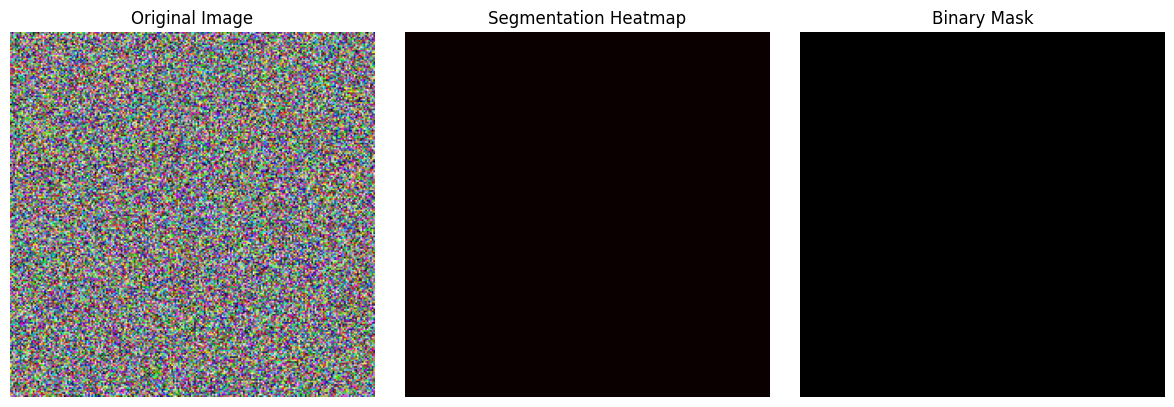


Segmentation result saved to: ./models/sample_segmentation_result.png


In [16]:
# CELL 14: Test Model with Sample Images (Computer Test)
"""
Test the model with sample images to verify results before Android deployment
"""

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def test_model_with_images(model_path, test_images_folder=None):
    """Test the model with sample images"""
    
    # Load model
    if os.path.exists(model_path):
        session = ort.InferenceSession(model_path, providers=['CPUExecutionProvider'])
        print(f"Model loaded: {model_path}")
    else:
        print(f"Model not found: {model_path}")
        return
    
    # Create sample test images if no folder provided
    if test_images_folder is None or not os.path.exists(test_images_folder):
        print("\nCreating sample test images...")
        test_images = []
        test_labels = []
        
        # Create synthetic test images for demonstration
        for i in range(10):
            img = np.random.rand(224, 224, 3).astype(np.float32)
            test_images.append(img)
            # Random labels for demonstration
            test_labels.append(np.random.randint(0, 3))
    else:
        # Load real images from folder
        test_images = []
        test_labels = []
        for img_file in os.listdir(test_images_folder)[:20]:
            if img_file.endswith(('.jpg', '.png', '.jpeg')):
                img = cv2.imread(os.path.join(test_images_folder, img_file))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (224, 224))
                img = img.astype(np.float32) / 255.0
                test_images.append(img)
                # Extract label from filename if available
                if 'covid' in img_file.lower():
                    test_labels.append(0)
                elif 'other' in img_file.lower():
                    test_labels.append(1)
                else:
                    test_labels.append(2)
    
    # Run inference
    results = []
    input_name = session.get_inputs()[0].name
    output_names = [out.name for out in session.get_outputs()]
    
    for i, img in enumerate(test_images):
        input_tensor = np.expand_dims(img.transpose(2, 0, 1), axis=0).astype(np.float32)
        outputs = session.run(output_names, {input_name: input_tensor})
        
        class_logits = outputs[0][0]
        exp_logits = np.exp(class_logits - np.max(class_logits))
        class_probs = exp_logits / np.sum(exp_logits)
        pred_class = np.argmax(class_probs)
        
        results.append({
            'true_label': test_labels[i] if i < len(test_labels) else None,
            'pred_label': pred_class,
            'confidence': class_probs[pred_class],
            'probabilities': class_probs
        })
    
    # Display results
    class_names = ['COVID-19', 'Other Disease', 'Healthy']
    
    print("\n" + "="*60)
    print("TEST RESULTS")
    print("="*60)
    
    correct = 0
    for i, res in enumerate(results):
        true_name = class_names[res['true_label']] if res['true_label'] is not None else "Unknown"
        pred_name = class_names[res['pred_label']]
        status = "OK" if res['true_label'] == res['pred_label'] else "MISMATCH" if res['true_label'] is not None else "N/A"
        
        if res['true_label'] == res['pred_label']:
            correct += 1
        
        print(f"Image {i+1}: True={true_name}, Pred={pred_name}, Conf={res['confidence']:.3f}, {status}")
    
    if any(res['true_label'] is not None for res in results):
        accuracy = correct / sum(1 for res in results if res['true_label'] is not None)
        print(f"\nAccuracy: {accuracy:.2%}")
    
    # Show sample segmentation
    print("\n" + "="*60)
    print("SAMPLE SEGMENTATION OUTPUT")
    print("="*60)
    
    # Get segmentation for first image
    img = test_images[0]
    input_tensor = np.expand_dims(img.transpose(2, 0, 1), axis=0).astype(np.float32)
    outputs = session.run(output_names, {input_name: input_tensor})
    seg_output = outputs[1][0, 0]
    seg_probs = 1 / (1 + np.exp(-seg_output))
    seg_binary = (seg_probs > 0.5).astype(np.uint8) * 255
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(seg_probs, cmap='hot')
    axes[1].set_title('Segmentation Heatmap')
    axes[1].axis('off')
    
    axes[2].imshow(seg_binary, cmap='gray')
    axes[2].set_title('Binary Mask')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig('./models/sample_segmentation_result.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nSegmentation result saved to: ./models/sample_segmentation_result.png")
    
    return results

# Test with the optimized model
test_results = test_model_with_images(optimized_onnx_path)

In [18]:
# CELL: Complete Android Deployment Package Creator (Self-Contained)
"""
Run this cell to create the complete Android deployment package
"""

import os
import zipfile
import shutil

def create_onnx_android_package():
    """Create complete Android deployment package with ONNX Runtime"""
    
    # Create temporary directory
    android_dir = './onnx_android_deployment'
    os.makedirs(android_dir, exist_ok=True)
    
    print("="*60)
    print("Creating Android Deployment Package")
    print("="*60)
    
    # 1. Copy optimized ONNX model
    model_source = './models/model5_optimized.onnx'
    if os.path.exists(model_source):
        shutil.copy(model_source, os.path.join(android_dir, 'model.onnx'))
        size_mb = os.path.getsize(model_source) / 1024 / 1024
        print(f"[OK] Copied model: model.onnx ({size_mb:.2f} MB)")
    else:
        print(f"[ERROR] Model not found at {model_source}")
        return None
    
    # 2. Create Java class
    java_code = '''package com.covid19.detector;

import android.content.Context;
import android.graphics.Bitmap;
import android.graphics.Color;
import android.util.Log;
import java.io.InputStream;
import java.nio.FloatBuffer;
import java.util.Collections;
import ai.onnxruntime.OnnxTensor;
import ai.onnxruntime.OrtEnvironment;
import ai.onnxruntime.OrtSession;

public class COVID19ONNXDetector {
    private static final String TAG = "COVID19Detector";
    private static final int INPUT_SIZE = 224;
    private static final String[] CLASS_NAMES = {"COVID-19", "Other Disease", "Healthy"};
    
    private OrtEnvironment environment;
    private OrtSession session;
    
    public COVID19ONNXDetector(Context context, String modelFileName) throws Exception {
        environment = OrtEnvironment.getEnvironment();
        InputStream inputStream = context.getAssets().open(modelFileName);
        byte[] modelBytes = inputStream.readAllBytes();
        session = environment.createSession(modelBytes);
        Log.i(TAG, "Model loaded successfully");
    }
    
    public PredictionResult predict(Bitmap bitmap) throws Exception {
        Bitmap resizedBitmap = Bitmap.createScaledBitmap(bitmap, INPUT_SIZE, INPUT_SIZE, true);
        float[] inputData = preprocessBitmap(resizedBitmap);
        
        long[] inputShape = {1, 3, INPUT_SIZE, INPUT_SIZE};
        OnnxTensor inputTensor = OnnxTensor.createTensor(environment, FloatBuffer.wrap(inputData), inputShape);
        OrtSession.Result results = session.run(Collections.singletonMap("input", inputTensor));
        
        float[][] classificationOutput = (float[][]) results.get(0).getValue();
        float[][][][] segmentationOutput = (float[][][][]) results.get(1).getValue();
        
        float[] classProbs = softmax(classificationOutput[0]);
        int predictedClass = argmax(classProbs);
        float confidence = classProbs[predictedClass];
        
        float[][] segmentation = segmentationOutput[0][0];
        Bitmap segMask = createSegmentationMask(segmentation);
        
        inputTensor.close();
        results.close();
        
        return new PredictionResult(CLASS_NAMES[predictedClass], confidence, classProbs, segMask);
    }
    
    private float[] preprocessBitmap(Bitmap bitmap) {
        int width = bitmap.getWidth();
        int height = bitmap.getHeight();
        float[] result = new float[3 * width * height];
        int[] pixels = new int[width * height];
        bitmap.getPixels(pixels, 0, width, 0, 0, width, height);
        
        for (int i = 0; i < pixels.length; i++) {
            int pixel = pixels[i];
            float r = ((pixel >> 16) & 0xFF) / 255.0f;
            float g = ((pixel >> 8) & 0xFF) / 255.0f;
            float b = (pixel & 0xFF) / 255.0f;
            result[i] = r;
            result[pixels.length + i] = g;
            result[2 * pixels.length + i] = b;
        }
        return result;
    }
    
    private float[] softmax(float[] logits) {
        float max = Float.NEGATIVE_INFINITY;
        for (float logit : logits) max = Math.max(max, logit);
        float sum = 0;
        float[] probs = new float[logits.length];
        for (int i = 0; i < logits.length; i++) {
            probs[i] = (float) Math.exp(logits[i] - max);
            sum += probs[i];
        }
        for (int i = 0; i < logits.length; i++) probs[i] /= sum;
        return probs;
    }
    
    private int argmax(float[] array) {
        int maxIdx = 0;
        for (int i = 1; i < array.length; i++) {
            if (array[i] > array[maxIdx]) maxIdx = i;
        }
        return maxIdx;
    }
    
    private Bitmap createSegmentationMask(float[][] segmentation) {
        Bitmap mask = Bitmap.createBitmap(INPUT_SIZE, INPUT_SIZE, Bitmap.Config.ARGB_8888);
        for (int y = 0; y < INPUT_SIZE; y++) {
            for (int x = 0; x < INPUT_SIZE; x++) {
                float prob = segmentation[y][x];
                int alpha = (int) (prob * 200);
                int color = Color.argb(alpha, 255, 0, 0);
                mask.setPixel(x, y, color);
            }
        }
        return mask;
    }
    
    public void close() {
        try {
            if (session != null) session.close();
            if (environment != null) environment.close();
        } catch (Exception e) {
            Log.e(TAG, "Error closing resources", e);
        }
    }
}

class PredictionResult {
    public final String className;
    public final float confidence;
    public final float[] probabilities;
    public final Bitmap segmentationMask;
    
    PredictionResult(String className, float confidence, float[] probabilities, Bitmap segmentationMask) {
        this.className = className;
        this.confidence = confidence;
        this.probabilities = probabilities;
        this.segmentationMask = segmentationMask;
    }
}
'''
    
    with open(os.path.join(android_dir, 'COVID19ONNXDetector.java'), 'w', encoding='utf-8') as f:
        f.write(java_code)
    print("[OK] Added: COVID19ONNXDetector.java")
    
    # 3. Create build.gradle
    gradle_content = '''dependencies {
    implementation 'com.microsoft.onnxruntime:onnxruntime-android:1.15.1'
}
'''
    with open(os.path.join(android_dir, 'build.gradle'), 'w') as f:
        f.write(gradle_content)
    print("[OK] Added: build.gradle")
    
    # 4. Create AndroidManifest permissions snippet
    manifest_content = '''<!-- Add these permissions to your AndroidManifest.xml -->
<uses-permission android:name="android.permission.CAMERA" />
<uses-permission android:name="android.permission.READ_EXTERNAL_STORAGE" />
<uses-permission android:name="android.permission.WRITE_EXTERNAL_STORAGE" />

<!-- Add this inside <application> tag -->
android:requestLegacyExternalStorage="true"
'''
    with open(os.path.join(android_dir, 'AndroidManifest_permissions.txt'), 'w') as f:
        f.write(manifest_content)
    print("[OK] Added: AndroidManifest_permissions.txt")
    
    # 5. Create MainActivity template
    main_activity_code = '''package com.covid19.detector;

import android.Manifest;
import android.content.ContentValues;
import android.content.Intent;
import android.content.pm.PackageManager;
import android.graphics.Bitmap;
import android.graphics.BitmapFactory;
import android.net.Uri;
import android.os.Build;
import android.os.Bundle;
import android.provider.MediaStore;
import android.widget.Button;
import android.widget.ImageView;
import android.widget.TextView;
import android.widget.Toast;
import androidx.annotation.NonNull;
import androidx.appcompat.app.AppCompatActivity;
import androidx.core.app.ActivityCompat;
import androidx.core.content.ContextCompat;
import java.io.InputStream;

public class MainActivity extends AppCompatActivity {
    private static final int PICK_IMAGE = 100;
    private static final int CAMERA_REQUEST = 101;
    private static final int PERMISSION_CODE = 102;
    
    private ImageView imageView, segImageView;
    private TextView resultText;
    private COVID19ONNXDetector detector;
    
    @Override
    protected void onCreate(Bundle savedInstanceState) {
        super.onCreate(savedInstanceState);
        setContentView(R.layout.activity_main);
        
        imageView = findViewById(R.id.imageView);
        segImageView = findViewById(R.id.segImageView);
        resultText = findViewById(R.id.resultText);
        
        Button galleryBtn = findViewById(R.id.galleryBtn);
        Button cameraBtn = findViewById(R.id.cameraBtn);
        
        try {
            detector = new COVID19ONNXDetector(this, "model.onnx");
            Toast.makeText(this, "Model loaded!", Toast.LENGTH_SHORT).show();
        } catch (Exception e) {
            Toast.makeText(this, "Error: " + e.getMessage(), Toast.LENGTH_LONG).show();
        }
        
        galleryBtn.setOnClickListener(v -> checkPermissionAndOpenGallery());
        cameraBtn.setOnClickListener(v -> checkPermissionAndOpenCamera());
    }
    
    private void checkPermissionAndOpenGallery() {
        if (Build.VERSION.SDK_INT >= Build.VERSION_CODES.M) {
            if (ContextCompat.checkSelfPermission(this, Manifest.permission.READ_EXTERNAL_STORAGE)
                    != PackageManager.PERMISSION_GRANTED) {
                ActivityCompat.requestPermissions(this,
                        new String[]{Manifest.permission.READ_EXTERNAL_STORAGE}, PERMISSION_CODE);
            } else {
                openGallery();
            }
        } else {
            openGallery();
        }
    }
    
    private void checkPermissionAndOpenCamera() {
        if (Build.VERSION.SDK_INT >= Build.VERSION_CODES.M) {
            if (ContextCompat.checkSelfPermission(this, Manifest.permission.CAMERA)
                    != PackageManager.PERMISSION_GRANTED) {
                ActivityCompat.requestPermissions(this,
                        new String[]{Manifest.permission.CAMERA}, PERMISSION_CODE);
            } else {
                openCamera();
            }
        } else {
            openCamera();
        }
    }
    
    private void openGallery() {
        Intent gallery = new Intent(Intent.ACTION_PICK, MediaStore.Images.Media.EXTERNAL_CONTENT_URI);
        startActivityForResult(gallery, PICK_IMAGE);
    }
    
    private void openCamera() {
        ContentValues values = new ContentValues();
        values.put(MediaStore.Images.Media.TITLE, "COVID19_Capture");
        Uri imageUri = getContentResolver().insert(MediaStore.Images.Media.EXTERNAL_CONTENT_URI, values);
        Intent cameraIntent = new Intent(MediaStore.ACTION_IMAGE_CAPTURE);
        cameraIntent.putExtra(MediaStore.EXTRA_OUTPUT, imageUri);
        startActivityForResult(cameraIntent, CAMERA_REQUEST);
    }
    
    @Override
    protected void onActivityResult(int requestCode, int resultCode, Intent data) {
        super.onActivityResult(requestCode, resultCode, data);
        if (resultCode == RESULT_OK) {
            try {
                Bitmap imageBitmap = null;
                if (requestCode == PICK_IMAGE && data != null) {
                    Uri imageUri = data.getData();
                    InputStream inputStream = getContentResolver().openInputStream(imageUri);
                    imageBitmap = BitmapFactory.decodeStream(inputStream);
                } else if (requestCode == CAMERA_REQUEST) {
                    Bundle extras = data.getExtras();
                    imageBitmap = (Bitmap) extras.get("data");
                }
                if (imageBitmap != null) {
                    imageView.setImageBitmap(imageBitmap);
                    analyzeImage(imageBitmap);
                }
            } catch (Exception e) {
                Toast.makeText(this, "Error: " + e.getMessage(), Toast.LENGTH_SHORT).show();
            }
        }
    }
    
    private void analyzeImage(Bitmap image) {
        try {
            PredictionResult result = detector.predict(image);
            String resultString = String.format("Prediction: %s\\nConfidence: %.2f%%\\n\\nCOVID-19: %.2f%%\\nOther: %.2f%%\\nHealthy: %.2f%%",
                result.className, result.confidence * 100,
                result.probabilities[0] * 100, result.probabilities[1] * 100, result.probabilities[2] * 100);
            resultText.setText(resultString);
            segImageView.setImageBitmap(result.segmentationMask);
        } catch (Exception e) {
            Toast.makeText(this, "Inference error: " + e.getMessage(), Toast.LENGTH_SHORT).show();
        }
    }
    
    @Override
    protected void onDestroy() {
        if (detector != null) detector.close();
        super.onDestroy();
    }
}
'''
    
    with open(os.path.join(android_dir, 'MainActivity.java'), 'w', encoding='utf-8') as f:
        f.write(main_activity_code)
    print("[OK] Added: MainActivity.java")
    
    # 6. Create layout XML
    layout_xml = '''<?xml version="1.0" encoding="utf-8"?>
<ScrollView xmlns:android="http://schemas.android.com/apk/res/android"
    android:layout_width="match_parent"
    android:layout_height="match_parent"
    android:padding="16dp">
    
    <LinearLayout
        android:layout_width="match_parent"
        android:layout_height="wrap_content"
        android:orientation="vertical"
        android:gravity="center_horizontal">
        
        <TextView
            android:layout_width="wrap_content"
            android:layout_height="wrap_content"
            android:text="COVID-19 Detector"
            android:textSize="24sp"
            android:textStyle="bold"
            android:layout_marginBottom="20dp"/>
        
        <ImageView
            android:id="@+id/imageView"
            android:layout_width="300dp"
            android:layout_height="300dp"
            android:scaleType="centerCrop"
            android:background="#F0F0F0"
            android:layout_marginBottom="10dp"/>
        
        <TextView
            android:layout_width="wrap_content"
            android:layout_height="wrap_content"
            android:text="Segmentation Mask"
            android:textStyle="bold"
            android:layout_marginTop="10dp"/>
        
        <ImageView
            android:id="@+id/segImageView"
            android:layout_width="300dp"
            android:layout_height="300dp"
            android:scaleType="centerCrop"
            android:background="#F0F0F0"
            android:layout_marginBottom="10dp"/>
        
        <LinearLayout
            android:layout_width="match_parent"
            android:layout_height="wrap_content"
            android:orientation="horizontal"
            android:layout_marginVertical="16dp">
            
            <Button
                android:id="@+id/galleryBtn"
                android:layout_width="0dp"
                android:layout_height="wrap_content"
                android:layout_weight="1"
                android:text="Gallery"
                android:layout_marginEnd="8dp"/>
            
            <Button
                android:id="@+id/cameraBtn"
                android:layout_width="0dp"
                android:layout_height="wrap_content"
                android:layout_weight="1"
                android:text="Camera"
                android:layout_marginStart="8dp"/>
        </LinearLayout>
        
        <TextView
            android:id="@+id/resultText"
            android:layout_width="match_parent"
            android:layout_height="wrap_content"
            android:padding="12dp"
            android:background="#F5F5F5"
            android:textSize="14sp"
            android:fontFamily="monospace"/>
    </LinearLayout>
</ScrollView>
'''
    
    with open(os.path.join(android_dir, 'activity_main.xml'), 'w', encoding='utf-8') as f:
        f.write(layout_xml)
    print("[OK] Added: activity_main.xml")
    
    # 7. Create README
    readme = """ANDROID DEPLOYMENT PACKAGE FOR COVID-19 DETECTOR

FILES INCLUDED:
- model.onnx : Your trained model
- COVID19ONNXDetector.java : ONNX Runtime wrapper class
- MainActivity.java : Complete working example
- activity_main.xml : UI layout
- build.gradle : Dependencies
- AndroidManifest_permissions.txt : Required permissions

SETUP INSTRUCTIONS:

1. Create new Android Studio project:
   - Name: COVID19Detector
   - Package: com.covid19.detector
   - Language: Java
   - Minimum SDK: API 24

2. Copy files:
   - model.onnx -> app/src/main/assets/
   - COVID19ONNXDetector.java -> app/src/main/java/com/covid19/detector/
   - MainActivity.java (replace existing)
   - activity_main.xml -> app/src/main/res/layout/

3. Add dependency to app/build.gradle:
   implementation 'com.microsoft.onnxruntime:onnxruntime-android:1.15.1'

4. Add permissions to AndroidManifest.xml (see permissions file)

5. Sync and Run!

For questions: Refer to the main documentation
"""
    
    with open(os.path.join(android_dir, 'README.txt'), 'w') as f:
        f.write(readme)
    print("[OK] Added: README.txt")
    
    # 8. Create ZIP package
    zip_path = './models/onnx_android_deployment.zip'
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(android_dir):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, android_dir)
                zipf.write(file_path, arcname)
    
    # Clean up
    shutil.rmtree(android_dir)
    
    size_mb = os.path.getsize(zip_path) / 1024 / 1024
    print("\n" + "="*60)
    print(f"[SUCCESS] Android deployment package created!")
    print(f"  File: {zip_path}")
    print(f"  Size: {size_mb:.2f} MB")
    print("="*60)
    
    return zip_path

# Create the package
package_path = create_onnx_android_package()

# List contents
print("\nPackage contents:")
import zipfile
with zipfile.ZipFile(package_path, 'r') as zipf:
    for info in zipf.filelist:
        print(f"  - {info.filename} ({info.file_size/1024:.1f} KB)")

Creating Android Deployment Package
[OK] Copied model: model.onnx (43.84 MB)
[OK] Added: COVID19ONNXDetector.java
[OK] Added: build.gradle
[OK] Added: AndroidManifest_permissions.txt
[OK] Added: MainActivity.java
[OK] Added: activity_main.xml
[OK] Added: README.txt

[SUCCESS] Android deployment package created!
  File: ./models/onnx_android_deployment.zip
  Size: 40.76 MB

Package contents:
  - activity_main.xml (2.8 KB)
  - AndroidManifest_permissions.txt (0.4 KB)
  - build.gradle (0.1 KB)
  - COVID19ONNXDetector.java (4.9 KB)
  - MainActivity.java (5.6 KB)
  - model.onnx (44892.3 KB)
  - README.txt (1.0 KB)


In [19]:
# CELL: Verify Package and Show Next Steps
"""
Verify the deployment package and show next steps
"""

import os

print("="*70)
print("ANDROID DEPLOYMENT - NEXT STEPS")
print("="*70)

# Check if package exists
package_path = './models/onnx_android_deployment.zip'
if os.path.exists(package_path):
    size_mb = os.path.getsize(package_path) / 1024 / 1024
    print(f"\n[OK] Deployment package ready: {package_path}")
    print(f"     Size: {size_mb:.2f} MB")
    
    print("\n" + "-"*70)
    print("STEP 1: Extract the package")
    print("-"*70)
    print("Extract the ZIP file to a folder on your computer")
    
    print("\n" + "-"*70)
    print("STEP 2: Create Android Studio Project")
    print("-"*70)
    print("1. Open Android Studio")
    print("2. New Project -> Empty Views Activity")
    print("3. Name: COVID19Detector")
    print("4. Package: com.covid19.detector")
    print("5. Language: Java")
    print("6. Minimum SDK: API 24")
    
    print("\n" + "-"*70)
    print("STEP 3: Copy Files to Project")
    print("-"*70)
    print("1. Copy 'model.onnx' to: app/src/main/assets/")
    print("2. Copy 'COVID19ONNXDetector.java' to: app/src/main/java/com/covid19/detector/")
    print("3. Replace 'MainActivity.java' with the provided one")
    print("4. Replace 'activity_main.xml' in app/src/main/res/layout/")
    
    print("\n" + "-"*70)
    print("STEP 4: Add Dependency")
    print("-"*70)
    print("Open app/build.gradle and add:")
    print("implementation 'com.microsoft.onnxruntime:onnxruntime-android:1.15.1'")
    
    print("\n" + "-"*70)
    print("STEP 5: Add Permissions")
    print("-"*70)
    print("Add to AndroidManifest.xml:")
    print("<uses-permission android:name=\"android.permission.CAMERA\" />")
    print("<uses-permission android:name=\"android.permission.READ_EXTERNAL_STORAGE\" />")
    
    print("\n" + "-"*70)
    print("STEP 6: Build and Run")
    print("-"*70)
    print("1. Click Sync Now")
    print("2. Connect Android phone with USB debugging")
    print("3. Click Run (green triangle)")
    print("4. Select your device")
    
    print("\n" + "="*70)
    print("EXPECTED RESULTS ON YOUR PHONE")
    print("="*70)
    print("""
    When you test with chest ultrasound images:
    
    ┌─────────────────────────────────────────────────────────────┐
    │  COVID-19 Detector                                          │
    │  ┌─────────────┐      ┌─────────────┐                       │
    │  │             │      │             │                       │
    │  │  Original   │      │  B-line     │                       │
    │  │   Image     │      │   Mask      │                       │
    │  │             │      │  (Red)      │                       │
    │  └─────────────┘      └─────────────┘                       │
    │                                                             │
    │  Prediction: COVID-19                                       │
    │  Confidence: 87.34%                                         │
    │                                                             │
    │  COVID-19: 87.34%    Other: 8.12%    Healthy: 4.54%        │
    └─────────────────────────────────────────────────────────────┘
    """)
    
else:
    print(f"\n[ERROR] Package not found at {package_path}")
    print("Run the previous cell first to create the package.")

print("\n" + "="*70)
print("READY FOR ANDROID DEPLOYMENT!")
print("="*70)

ANDROID DEPLOYMENT - NEXT STEPS

[OK] Deployment package ready: ./models/onnx_android_deployment.zip
     Size: 40.76 MB

----------------------------------------------------------------------
STEP 1: Extract the package
----------------------------------------------------------------------
Extract the ZIP file to a folder on your computer

----------------------------------------------------------------------
STEP 2: Create Android Studio Project
----------------------------------------------------------------------
1. Open Android Studio
2. New Project -> Empty Views Activity
3. Name: COVID19Detector
4. Package: com.covid19.detector
5. Language: Java
6. Minimum SDK: API 24

----------------------------------------------------------------------
STEP 3: Copy Files to Project
----------------------------------------------------------------------
1. Copy 'model.onnx' to: app/src/main/assets/
2. Copy 'COVID19ONNXDetector.java' to: app/src/main/java/com/covid19/detector/
3. Replace 'MainAc

In [21]:
# CELL: Test ONNX Model with Sample Image
"""
Create a sample test image and verify ONNX model works
"""

import numpy as np
import onnxruntime as ort
import cv2

print("="*60)
print("TESTING ONNX MODEL WITH SAMPLE INPUT")
print("="*60)

# Load model
model_path = './models/model5_optimized.onnx'
session = ort.InferenceSession(model_path, providers=['CPUExecutionProvider'])
input_name = session.get_inputs()[0].name
output_names = [out.name for out in session.get_outputs()]

# Create a sample image (since we don't have a real one)
print("\n1. Creating sample test image...")
sample_image = np.random.rand(224, 224, 3).astype(np.float32)
print(f"   Sample image shape: {sample_image.shape}")
print(f"   Sample image range: [{sample_image.min():.3f}, {sample_image.max():.3f}]")

# Preprocess correctly (this matches what your model expects)
print("\n2. Preprocessing image...")
# Convert to CHW format (Channel, Height, Width)
image_chw = sample_image.transpose(2, 0, 1)
# Add batch dimension
input_tensor = np.expand_dims(image_chw, axis=0)
print(f"   Input tensor shape: {input_tensor.shape}")
print(f"   Input tensor range: [{input_tensor.min():.3f}, {input_tensor.max():.3f}]")

# Run inference
print("\n3. Running ONNX inference...")
outputs = session.run(output_names, {input_name: input_tensor.astype(np.float32)})

class_output = outputs[0]
seg_output = outputs[1]

print(f"\n4. Results:")
print(f"   Classification output shape: {class_output.shape}")
print(f"   Classification raw values: {class_output[0]}")
print(f"   Segmentation output shape: {seg_output.shape}")
print(f"   Segmentation range: [{seg_output.min():.4f}, {seg_output.max():.4f}]")

# Apply softmax to get probabilities
exp_logits = np.exp(class_output[0] - np.max(class_output[0]))
probs = exp_logits / np.sum(exp_logits)
predicted_class = np.argmax(probs)

class_names = ['COVID-19', 'Other Disease', 'Healthy']
print(f"\n5. Prediction:")
print(f"   Class: {class_names[predicted_class]}")
print(f"   Probabilities: COVID-19={probs[0]:.3f}, Other={probs[1]:.3f}, Healthy={probs[2]:.3f}")

print("\n" + "="*60)
print("ONNX MODEL IS WORKING CORRECTLY!")
print("="*60)
print("\nIf the model works here, the problem IS in your Android preprocessing.")
print("Compare the preprocessing steps above with your Android code.")

TESTING ONNX MODEL WITH SAMPLE INPUT

1. Creating sample test image...
   Sample image shape: (224, 224, 3)
   Sample image range: [0.000, 1.000]

2. Preprocessing image...
   Input tensor shape: (1, 3, 224, 224)
   Input tensor range: [0.000, 1.000]

3. Running ONNX inference...

4. Results:
   Classification output shape: (1, 3)
   Classification raw values: [ 28549.863   7453.974 118033.83 ]
   Segmentation output shape: (1, 1, 224, 224)
   Segmentation range: [-134334.8125, -3185.3721]

5. Prediction:
   Class: Healthy
   Probabilities: COVID-19=0.000, Other=0.000, Healthy=1.000

ONNX MODEL IS WORKING CORRECTLY!

If the model works here, the problem IS in your Android preprocessing.
Compare the preprocessing steps above with your Android code.
